In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)


In [77]:
# Cargar dataset de cancer de mama
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target  # 0 = maligno, 1 = benigno

print(f"Dimensiones: {df.shape}")
print(f"  0 → {data.target_names[0]} (maligno)")
print(f"  1 → {data.target_names[1]} (benigno)")
df.head()

Dimensiones: (569, 31)
  0 → malignant (maligno)
  1 → benign (benigno)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [78]:
# Checar datos faltantes y duplicados
print("Valores faltantes:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())
print("\nTipos de datos:")
print(df.dtypes.value_counts())

Valores faltantes: 0
Filas duplicadas: 0

Tipos de datos:
float64    30
int64       1
Name: count, dtype: int64


In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


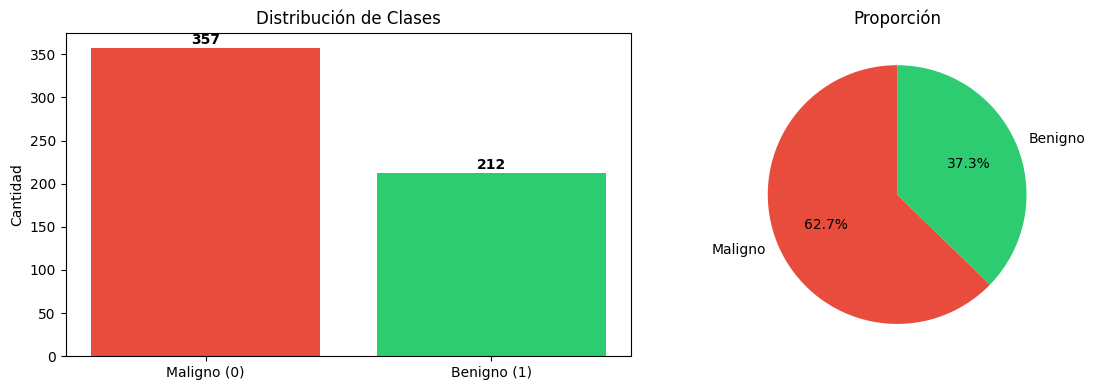

Maligno: 212 (37.3%)
Benigno: 357 (62.7%)


In [80]:
# Distribucion de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteo = df['diagnosis'].value_counts()

axes[0].bar(['Maligno (0)', 'Benigno (1)'], conteo.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribución de Clases')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['Maligno', 'Benigno'], autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Proporción')

plt.tight_layout()
plt.show()

print(f"Maligno: {conteo[0]} ({conteo[0]/len(df)*100:.1f}%)")
print(f"Benigno: {conteo[1]} ({conteo[1]/len(df)*100:.1f}%)")

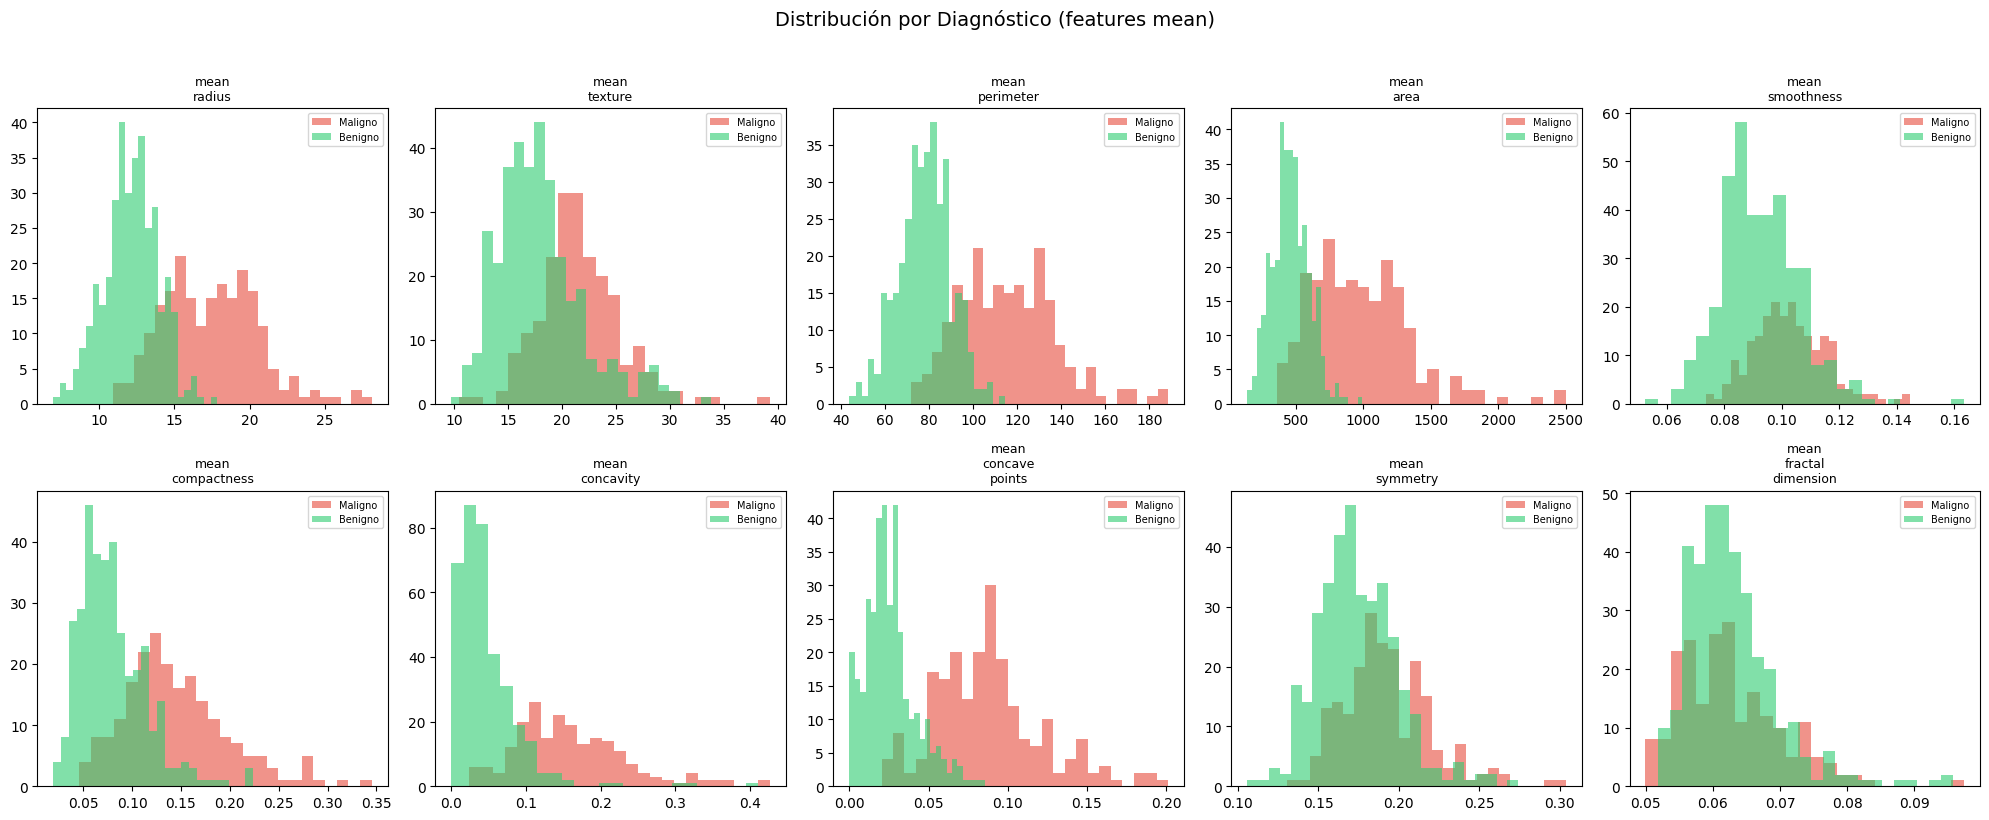

In [81]:
# Histogramas de las caracteristicas "mean"
feats_mean = [col for col in df.columns if 'mean' in col]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for i, feat in enumerate(feats_mean):
    axes[i].hist(df[df['diagnosis'] == 0][feat], bins=25, alpha=0.6, label='Maligno', color='#e74c3c')
    axes[i].hist(df[df['diagnosis'] == 1][feat], bins=25, alpha=0.6, label='Benigno', color='#2ecc71')
    axes[i].set_title(feat.replace(' ', '\n'), fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución por Diagnóstico (features mean)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

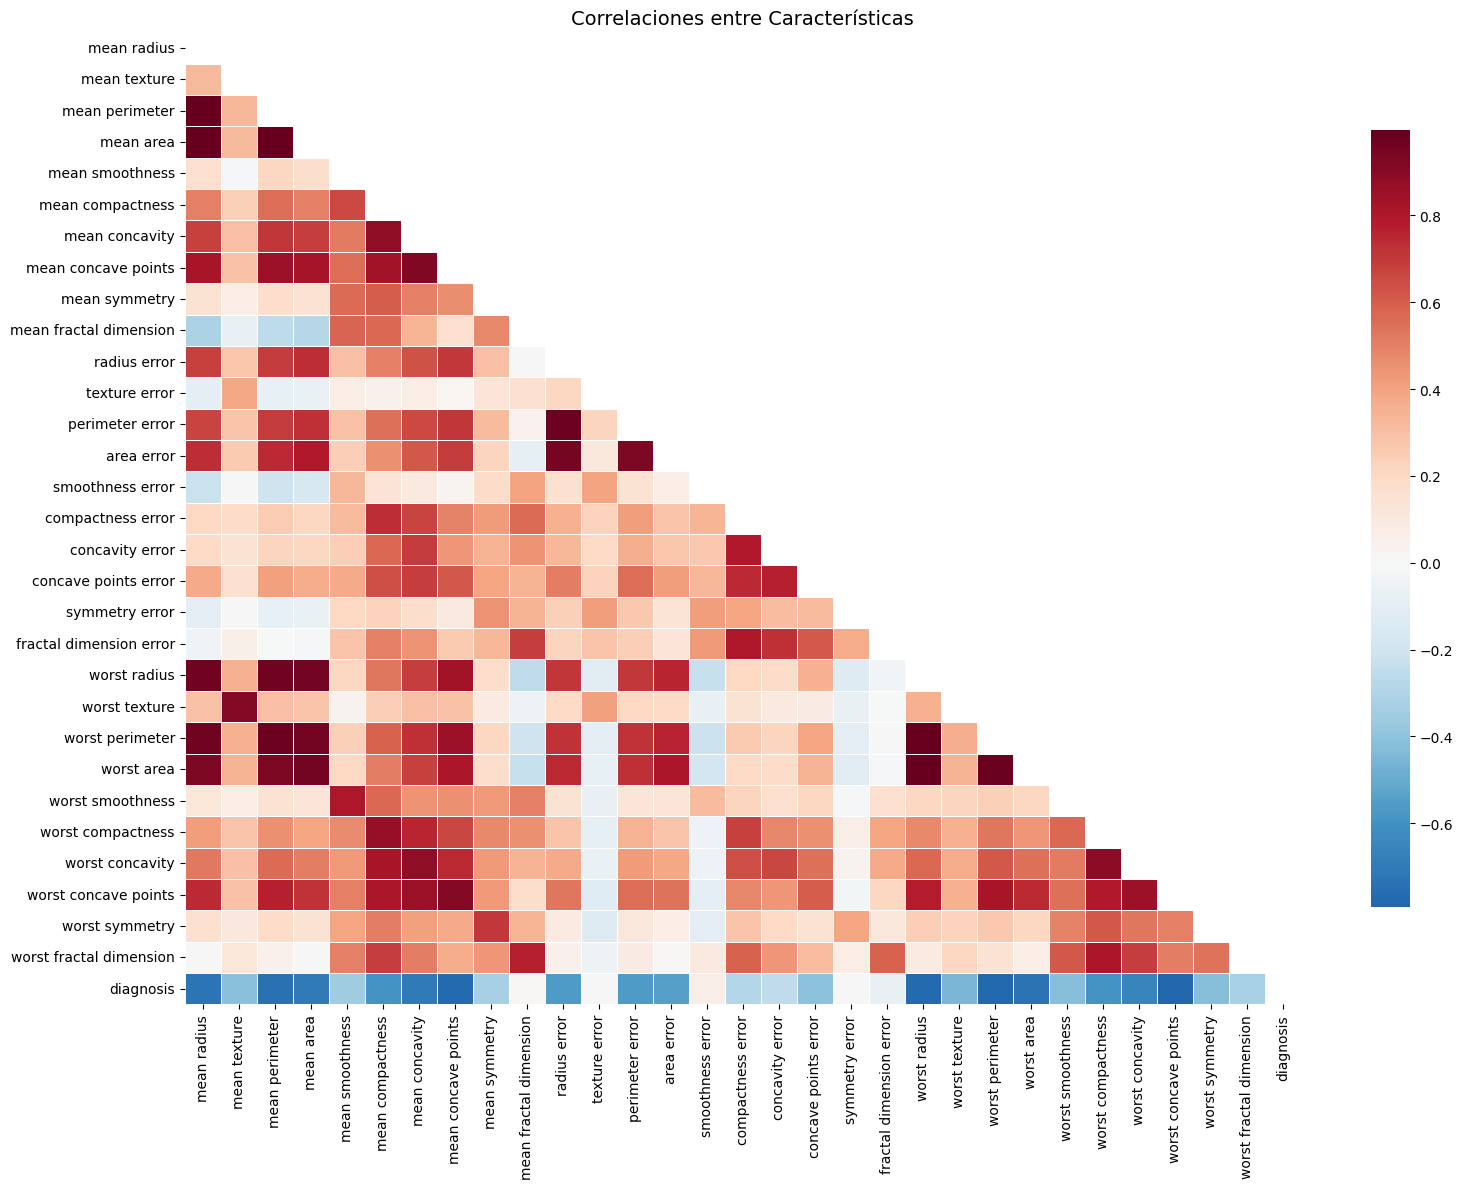

In [82]:
# Heatmap de correlaciones
plt.figure(figsize=(16, 12))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            annot=False, fmt='.2f', linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlaciones entre Características', fontsize=14)
plt.tight_layout()
plt.show()

In [83]:
# Features mas correlacionadas con el diagnostico
corr_target = corr['diagnosis'].drop('diagnosis').sort_values(ascending=False)
print("Top 10 correlaciones positivas (benigno):")
print(corr_target.head(10).to_string())
print("\nTop 10 correlaciones negativas (maligno):")
print(corr_target.tail(10).to_string())

Top 10 correlaciones positivas (benigno):
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560

Top 10 correlaciones negativas (maligno):
worst concavity        -0.659610
mean concavity         -0.696360
mean area              -0.708984
mean radius            -0.730029
worst area             -0.733825
mean perimeter         -0.742636
worst radius           -0.776454
mean concave points    -0.776614
worst perimeter        -0.782914
worst concave points   -0.793566


In [84]:
# Separar features y target
X = df.drop('diagnosis', axis=1).values
y = df['diagnosis'].values

# Split: 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# Estandarizar (fit solo en train)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

Train: 341, Val: 114, Test: 114


**Preparación PCA**
---
Calculamos la matriz de covarianza para ver cómo varían los datos juntos, y luego sacamos los autovalores.


In [85]:
# Matriz de covarianza
cov_matrix = np.cov(X_train_s.T)
print("Matriz de covarianza calculada.")

# Autovalores y autovectores
eigen_vals, eigen_vecs = np.linalg.eig(cov_matrix)
print("Autovalores encontrados:", eigen_vals)


Matriz de covarianza calculada.
Autovalores encontrados: [1.33129163e+01 5.88384619e+00 2.80337634e+00 2.01197805e+00
 1.71691522e+00 1.13005648e+00 6.46725224e-01 4.75570318e-01
 3.94526631e-01 3.78279502e-01 2.59704296e-01 2.44638523e-01
 2.09556446e-01 1.57036838e-01 9.79237898e-02 7.27499076e-02
 5.96981225e-02 5.28634945e-02 3.69382724e-02 2.99153009e-02
 2.66859380e-02 2.49276603e-02 1.27895822e-04 6.28315610e-04
 1.50417389e-03 5.78314547e-03 7.36461994e-03 1.67982887e-02
 1.57963919e-02 1.34036569e-02]


**Aplicamos Modelo PCA y Grafica**
---
Aquí vemos qué porcentaje de la información original se quedó en cada nuevo componente.


In [86]:
# creamos el modelo de pca
pca_modelo = PCA()
X_train_pca_total = pca_modelo.fit_transform(X_train_s)
X_val_pca_total = pca_modelo.transform(X_val_s)
X_test_pca_total = pca_modelo.transform(X_test_s)

# sacamos el porcentaje de info de cada uno
varianza = pca_modelo.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

print("paso pca: ya calculamos los componentes y esto es lo que explican:")
for i, v in enumerate(varianza):
    print(f"el componente {i+1} trae el {v*100:.2f}% de la info")


paso pca: ya calculamos los componentes y esto es lo que explican:
el componente 1 trae el 44.25% de la info
el componente 2 trae el 19.56% de la info
el componente 3 trae el 9.32% de la info
el componente 4 trae el 6.69% de la info
el componente 5 trae el 5.71% de la info
el componente 6 trae el 3.76% de la info
el componente 7 trae el 2.15% de la info
el componente 8 trae el 1.58% de la info
el componente 9 trae el 1.31% de la info
el componente 10 trae el 1.26% de la info
el componente 11 trae el 0.86% de la info
el componente 12 trae el 0.81% de la info
el componente 13 trae el 0.70% de la info
el componente 14 trae el 0.52% de la info
el componente 15 trae el 0.33% de la info
el componente 16 trae el 0.24% de la info
el componente 17 trae el 0.20% de la info
el componente 18 trae el 0.18% de la info
el componente 19 trae el 0.12% de la info
el componente 20 trae el 0.10% de la info
el componente 21 trae el 0.09% de la info
el componente 22 trae el 0.08% de la info
el componente 23

**Gráfico de codo para decidir**
---
Este gráfico nos ayuda a decidir cuántos componentes conservar para entrenar el modelo con PCA.


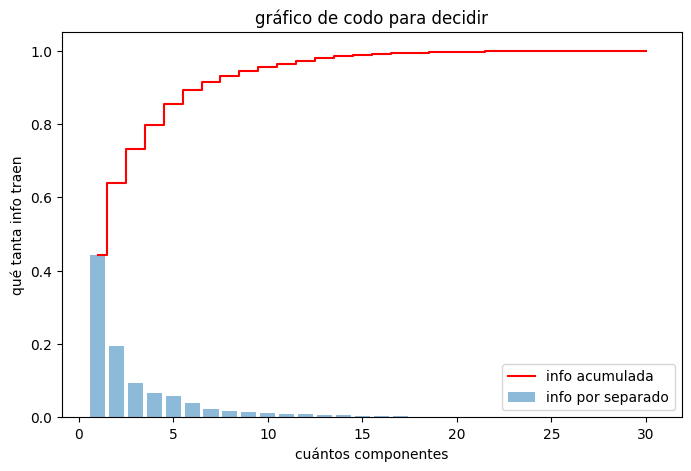

paso pca: graficar


In [87]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(varianza) + 1), varianza, alpha=0.5, label='info por separado')
plt.step(range(1, len(varianza_acum) + 1), varianza_acum, where='mid', label='info acumulada', color='red')
plt.xlabel('cuántos componentes')
plt.ylabel('qué tanta info traen')
plt.title('gráfico de codo para decidir')
plt.legend()
plt.show()

print("paso pca: graficar")


**Reducimos los datos con PCA**
---
Tomamos 8 componentes principales para entrenar el mismo modelo de una sola neurona, pero ahora con PCA añadido.


In [88]:
n_componentes = 8

X_train_pca = X_train_pca_total[:, :n_componentes]
X_val_pca = X_val_pca_total[:, :n_componentes]
X_test_pca = X_test_pca_total[:, :n_componentes]

print(f"Train PCA: {X_train_pca.shape}")
print(f"Val PCA: {X_val_pca.shape}")
print(f"Test PCA: {X_test_pca.shape}")


Train PCA: (341, 8)
Val PCA: (114, 8)
Test PCA: (114, 8)


In [89]:
# Modelo de una sola neurona (sigmoide)
lr = 0.001
epocas = 100
batch = 32

modelo = keras.Sequential([
    layers.Dense(1, activation='sigmoid', input_shape=(X_train_s.shape[1],))
])
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
modelo.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [90]:
# Entrenar
historial = modelo.fit(
    X_train_s, y_train,
    epochs=epocas,
    batch_size=batch,
    validation_data=(X_val_s, y_val),
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2086 - loss: 1.4776 - val_accuracy: 0.1842 - val_loss: 1.3472
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2310 - loss: 1.3619 - val_accuracy: 0.1930 - val_loss: 1.2464
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2475 - loss: 1.2522 - val_accuracy: 0.2193 - val_loss: 1.1517
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2651 - loss: 1.1492 - val_accuracy: 0.2807 - val_loss: 1.0637
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3006 - loss: 1.0536 - val_accuracy: 0.3246 - val_loss: 0.9827
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3561 - loss: 0.9660 - val_accuracy: 0.3772 - val_loss: 0.9091
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3913 - loss: 0.8863 - val_accuracy: 0.4825 - val_loss: 0.8425
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4456 - loss: 0.8146 - val_accuracy: 0.5526 - 

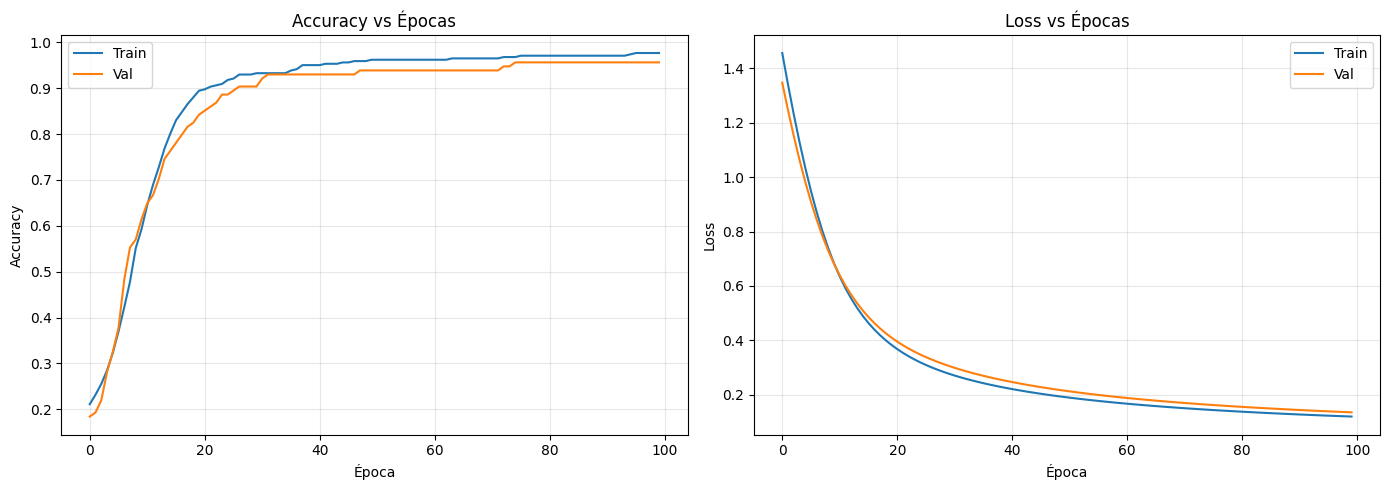

In [91]:
# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial.history['accuracy'], label='Train')
axes[0].plot(historial.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy vs Épocas')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historial.history['loss'], label='Train')
axes[1].plot(historial.history['val_loss'], label='Val')
axes[1].set_title('Loss vs Épocas')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

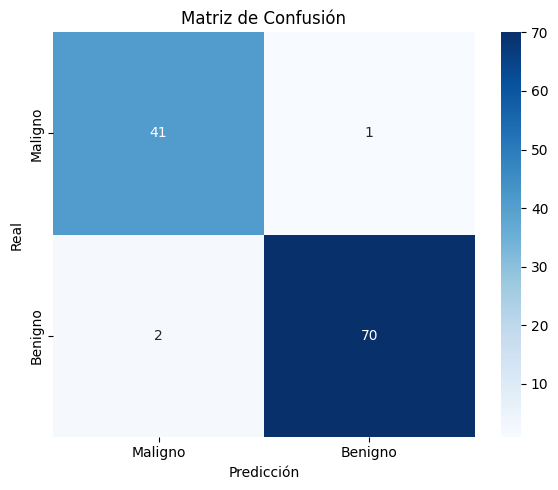

Accuracy:      0.9737
Precision:     0.9859
Recall:        0.9722
Especificidad: 0.9762
F1-score:      0.9790


In [92]:
# Evaluacion en test
y_pred_prob = modelo.predict(X_test_s, verbose=0)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

mc = confusion_matrix(y_test, y_pred)
vn, fp, fn, vp = mc.ravel()

# Metricas
accuracy = (vp + vn) / (vp + vn + fp + fn)
precision = vp / (vp + fp)
recall = vp / (vp + fn)
especificidad = vn / (vn + fp)
f1 = 2 * precision * recall / (precision + recall)

# Matriz de confusion
plt.figure(figsize=(6, 5))
sns.heatmap(mc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"F1-score:      {f1:.4f}")

In [93]:
# Guardar modelo
modelo.save('neurona_unica_original.keras')
print("Modelo guardado")

# Verificar que carga bien
modelo_cargado = keras.models.load_model('neurona_unica_original.keras')
loss, acc = modelo_cargado.evaluate(X_test_s, y_test, verbose=0)
print(f"Modelo cargado - Loss: {loss:.4f}, Acc: {acc:.4f}")

Modelo guardado
Modelo cargado - Loss: 0.1448, Acc: 0.9737


**Modelo de una sola neurona con PCA**
---
Usamos el mismo modelo de una sola neurona de la tarea 4, pero ahora entrenado con los datos reducidos por PCA.


In [94]:
modelo_pca = keras.Sequential([
    layers.Dense(1, activation='sigmoid', input_shape=(X_train_pca.shape[1],))
])
modelo_pca.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
modelo_pca.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [95]:
# Entrenar modelo con PCA
historial_pca = modelo_pca.fit(
    X_train_pca, y_train,
    epochs=epocas,
    batch_size=batch,
    validation_data=(X_val_pca, y_val),
    verbose=1
)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7942 - loss: 0.4750 - val_accuracy: 0.8246 - val_loss: 0.4533
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7942 - loss: 0.4618 - val_accuracy: 0.8246 - val_loss: 0.4426
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8003 - loss: 0.4493 - val_accuracy: 0.8246 - val_loss: 0.4324
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8169 - loss: 0.4374 - val_accuracy: 0.8421 - val_loss: 0.4225
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8333 - loss: 0.4260 - val_accuracy: 0.8596 - val_loss: 0.4131
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8434 - loss: 0.4151 - val_accuracy: 0.8596 - val_loss: 0.4041
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8644 - loss: 0.4047 - val_accuracy: 0.8596 - val_loss: 0.3955
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8658 - loss: 0.3947 - val_accuracy: 0.8596 - 

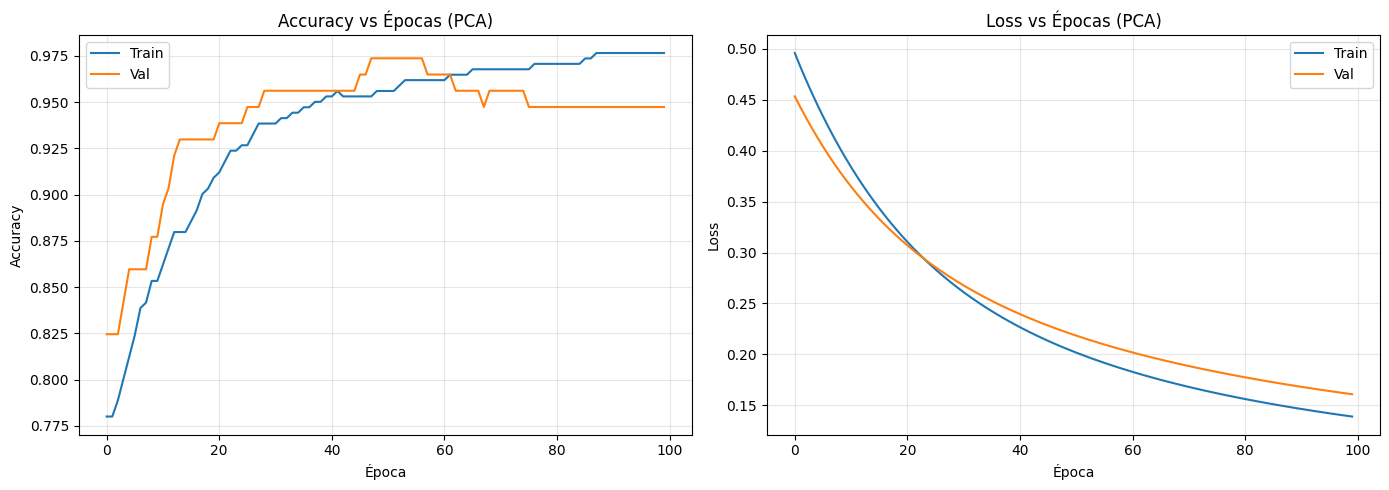

In [96]:
# Curvas de aprendizaje del modelo con PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial_pca.history['accuracy'], label='Train')
axes[0].plot(historial_pca.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy vs Épocas (PCA)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(historial_pca.history['loss'], label='Train')
axes[1].plot(historial_pca.history['val_loss'], label='Val')
axes[1].set_title('Loss vs Épocas (PCA)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


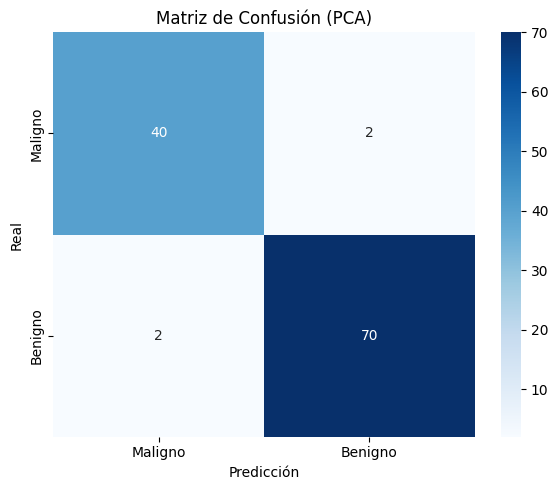

Accuracy PCA:      0.9649
Precision PCA:     0.9722
Recall PCA:        0.9722
Especificidad PCA: 0.9524
F1-score PCA:      0.9722


In [97]:
# Evaluacion en test del modelo con PCA
y_pred_prob_pca = modelo_pca.predict(X_test_pca, verbose=0)
y_pred_pca = (y_pred_prob_pca >= 0.5).astype(int).flatten()

mc_pca = confusion_matrix(y_test, y_pred_pca)
vn_pca, fp_pca, fn_pca, vp_pca = mc_pca.ravel()

accuracy_pca = (vp_pca + vn_pca) / (vp_pca + vn_pca + fp_pca + fn_pca)
precision_pca = vp_pca / (vp_pca + fp_pca)
recall_pca = vp_pca / (vp_pca + fn_pca)
especificidad_pca = vn_pca / (vn_pca + fp_pca)
f1_pca = 2 * precision_pca * recall_pca / (precision_pca + recall_pca)

plt.figure(figsize=(6, 5))
sns.heatmap(mc_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'])
plt.title('Matriz de Confusión (PCA)')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print(f"Accuracy PCA:      {accuracy_pca:.4f}")
print(f"Precision PCA:     {precision_pca:.4f}")
print(f"Recall PCA:        {recall_pca:.4f}")
print(f"Especificidad PCA: {especificidad_pca:.4f}")
print(f"F1-score PCA:      {f1_pca:.4f}")


**Comparación de los dos modelos**
---
Aquí comparamos el modelo original de una sola neurona contra el mismo modelo con PCA añadido.


In [98]:
comparacion = pd.DataFrame({
    'Modelo': ['Una neurona sin PCA', 'Una neurona con PCA'],
    'Accuracy': [accuracy, accuracy_pca],
    'Precision': [precision, precision_pca],
    'Recall': [recall, recall_pca],
    'Especificidad': [especificidad, especificidad_pca],
    'F1-score': [f1, f1_pca]
})

print(comparacion)


                Modelo  Accuracy  Precision    Recall  Especificidad  F1-score
0  Una neurona sin PCA  0.973684   0.985915  0.972222       0.976190  0.979021
1  Una neurona con PCA  0.964912   0.972222  0.972222       0.952381  0.972222


In [99]:
# Guardar modelo con PCA
modelo_pca.save('neurona_unica_pca.keras')
print("Modelo con PCA guardado")

modelo_pca_cargado = keras.models.load_model('neurona_unica_pca.keras')
loss_pca, acc_pca = modelo_pca_cargado.evaluate(X_test_pca, y_test, verbose=0)
print(f"Modelo PCA cargado - Loss: {loss_pca:.4f}, Acc: {acc_pca:.4f}")


Modelo con PCA guardado
Modelo PCA cargado - Loss: 0.1705, Acc: 0.9649
